In [1]:
import pysam
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, auc, f1_score, roc_curve
from methylseqnet import dna_io, inference, metrics, peaks
import methylseqnet
from dimelo import load_processed, plot_enrichment_profile, utils
from matplotlib import pyplot as plt
import torch
import numpy as np

PATH does not include the conda environment /bin folder. Adding /global/home/users/dixonluinenburg/.conda/envs/methylseqnet/bin.
PATH is now /global/home/users/dixonluinenburg/.conda/envs/methylseqnet/bin:/global/software/sl-7.x86_64/modules/langs/python/3.10/bin:/global/software/sl-7.x86_64/modules/tools/sq/0.1.0/bin:/global/software/sl-7.x86_64/modules/tools/emacs/25.1/bin:/global/software/sl-7.x86_64/modules/tools/vim/7.4/bin:/usr/local/bin:/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/global/home/groups/allhands/bin:/global/home/users/dixonluinenburg/bin
modkit found with expected version 0.2.4


In [2]:
ref_genome = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'
pileup_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_ma/pileup.sorted.bed.gz'
pileup_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_ma/pileup.sorted.bed.gz'
bam_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/deep_ctcf_mod_mappings_merge_HP1_chrX.retagged.sorted.bam'
bam_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/deep_ctcf_mod_mappings_merge_HP2_chrX.retagged.sorted.bam'

In [3]:
# for bam_path in [bam_hp1_allcontext,bam_hp2_allcontext]:
#     bam = pysam.AlignmentFile(bam_path)
#     coverage = bam.count_coverage('chrX')
#     print(coverage)

In [4]:
t2t = pysam.FastaFile(ref_genome)
X_length = t2t.get_reference_length('chrX')

In [5]:
hp1_peaks = peaks.peaks_from_bedmethyl(
    bedmethyl_file=pileup_hp1_allcontext,
    fasta_file=ref_genome,
    chromosome='chrX',
)

In [6]:
hp2_peaks = peaks.peaks_from_bedmethyl(
    bedmethyl_file=pileup_hp2_allcontext,
    fasta_file=ref_genome,
    chromosome='chrX',
)

In [14]:
window_size = 1000

# Calculate the sum of True elements in each 500-element stretch
hp1_sums = hp1_peaks[0:(len(hp1_peaks)//window_size)*window_size].reshape(len(hp1_peaks)//window_size, window_size).sum(axis=1)
hp2_sums = hp2_peaks[0:(len(hp2_peaks)//window_size)*window_size].reshape(len(hp2_peaks)//window_size, window_size).sum(axis=1)

In [18]:
delta_array = np.abs(hp1_sums-hp2_sums)
# Get the indices of the top 6 maximum values
top_6_indices = np.argpartition(delta_array, -20)[-20:]

# Get the actual values and sort them to find the top values in correct order
top_6_indices = top_6_indices[np.argsort(-delta_array[top_6_indices])]

# Print out the indices and their corresponding values
for idx in top_6_indices:
    print(f"Index: {idx}, Value: {(hp1_sums-hp2_sums)[idx]}")

Index: 1192, Value: -72
Index: 1193, Value: -67
Index: 1016, Value: 56
Index: 151, Value: -51
Index: 379, Value: -50
Index: 1154, Value: -50
Index: 1003, Value: -45
Index: 1189, Value: -42
Index: 481, Value: -42
Index: 377, Value: -40
Index: 367, Value: -35
Index: 308, Value: -34
Index: 1000, Value: -34
Index: 219, Value: -34
Index: 374, Value: -33
Index: 922, Value: -32
Index: 355, Value: 31
Index: 88, Value: -31
Index: 409, Value: -31
Index: 152, Value: -29


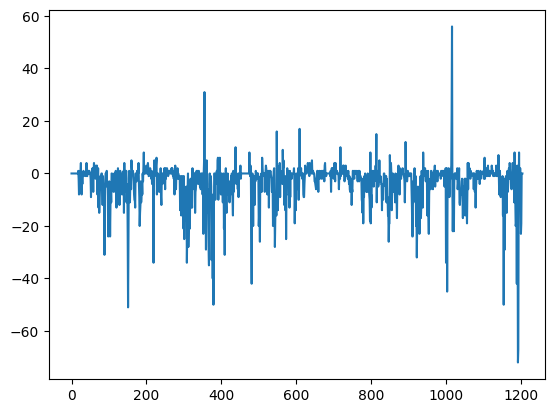

In [16]:
plt.plot(hp1_sums-hp2_sums)

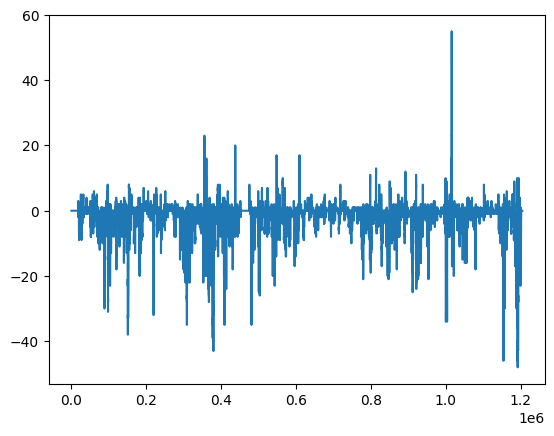

In [14]:
# plt.plot(sums1-sums2)